# HW 6 Analisi, Schema Mediato e Pre-processing dei Dati Automotive

Questo notebook implementa le prime fasi del progetto di integrazione dati tra **Craigslist** e **US Used Cars**:
1. **Analisi Esplorativa**: Percentuali di valori nulli e di valori unici per ciascun attributo delle sorgenti.
2. **Pulizia e Validazione del VIN**: Rimozione VIN rumorosi/invalidi (lunghezza diversa da 17 caratteri), deduplicazione e identificazione dei record comuni.
3. **Definizione dello Schema Mediato**: Mappatura degli schemi sorgente verso uno schema unificato comune.
4. **Pulizia e Normalizzazione dei Campi**: Standardizzazione di attributi categorici (`make`, `model`, `transmission`, `fuel`) e numerici (`price`, `mileage`, `year`) per la successiva fase di Record Linkage.

## Configurazione Ambiente e Dipendenze

In [94]:
%load_ext cudf.pandas
%pip install -q loguru

The cudf.pandas extension is already loaded. To reload it, use:
  %reload_ext cudf.pandas


In [95]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [96]:
import sys
import os
import time
import pandas as pd
from loguru import logger

os.environ['TZ'] = 'Europe/Rome'
time.tzset()

logger.remove()
logger.add(
    sys.stdout,
    colorize=True,
    format="<green>{time:YYYY-MM-DD HH:mm:ss}</green> | <level>{level: <8}</level> | <cyan>{message}</cyan>"
)

vehicles = pd.read_csv("/content/drive/MyDrive/data/vehicles.csv")
used_cars = pd.read_csv("/content/drive/MyDrive/data/used_cars_data.csv")

logger.info(f"Vehicles (Craigslist) caricato: {len(vehicles):,} righe")
logger.info(f"Used Cars caricato: {len(used_cars):,} righe")

2026-09-13 10:00:32 | INFO     | Vehicles (Craigslist) caricato: 426,880 righe
2026-09-13 10:00:32 | INFO     | Used Cars caricato: 3,000,040 righe


##Analisi dei Valori Nulli e Valori Unici

Per ciascuna sorgente analizziamo la percentuale di valori nulli e il numero di valori unici di ciascun attributo, come richiesto dalla prima consegna del progetto.

In [97]:
vehicles.describe()

,id,price,year,odometer,county,lat,long
count,4.268800e+05,4.268800e+05,425675.000000,4.224800e+05,0.0,420331.000000,420331.000000
mean,7.311487e+09,7.519903e+04,2011.235191,9.804333e+04,NaN,38.493940,-94.748599
std,4.473170e+06,1.218228e+07,9.452120,2.138815e+05,NaN,5.841533,18.365462
min,7.207408e+09,0.000000e+00,1900.000000,0.000000e+00,NaN,-84.122245,-159.827728
25%,7.308143e+09,5.900000e+03,2008.000000,3.770400e+04,NaN,34.601900,-111.939847
50%,7.312621e+09,1.395000e+04,2013.000000,8.554800e+04,NaN,39.150100,-88.432600
75%,7.315254e+09,2.648575e+04,2017.000000,1.335425e+05,NaN,42.398900,-80.832039
max,7.317101e+09,3.736929e+09,2022.000000,1.000000e+07,NaN,82.390818,173.885502


In [98]:
used_cars.describe()

,city_fuel_economy,combine_fuel_economy,daysonmarket,engine_displacement,highway_fuel_economy,horsepower,is_certified,latitude,listing_id,longitude,mileage,owner_count,price,savings_amount,seller_rating,sp_id,vehicle_damage_category,year
count,2.508755e+06,0.0,3.000040e+06,2.827654e+06,2.508755e+06,2.827654e+06,0.0,3.000040e+06,3.000040e+06,3.000040e+06,2.855653e+06,1.483027e+06,3.000040e+06,3.000040e+06,2.959168e+06,2.999944e+06,0.0,3.000040e+06
mean,2.269325e+01,NaN,7.605973e+01,2.968488e+03,2.947337e+01,2.479957e+02,NaN,3.698414e+01,2.754987e+08,-9.064224e+01,3.114690e+04,1.532644e+00,2.993337e+04,5.509768e+02,4.270413e+00,2.335224e+05,NaN,2.017728e+03
std,8.807024e+00,NaN,1.088839e+02,1.348905e+03,7.769252e+00,9.046639e+01,NaN,4.996819e+00,8.894123e+06,1.390589e+01,7.458675e+04,9.202928e-01,1.956617e+04,1.079448e+03,5.133017e-01,1.323221e+05,NaN,4.178701e+00
min,7.000000e+00,NaN,0.000000e+00,7.000000e+02,1.000000e+01,5.500000e+01,NaN,1.834670e+01,1.994620e+07,-1.579280e+02,0.000000e+00,1.000000e+00,1.650000e+02,0.000000e+00,1.000000e+00,4.159300e+04,NaN,1.915000e+03
25%,1.800000e+01,NaN,1.400000e+01,2.000000e+03,2.500000e+01,1.750000e+02,NaN,3.350920e+01,2.745794e+08,-9.708820e+01,6.000000e+00,1.000000e+00,1.845100e+04,0.000000e+00,4.000000e+00,6.337500e+04,NaN,2.017000e+03
50%,2.100000e+01,NaN,3.500000e+01,2.500000e+03,2.900000e+01,2.440000e+02,NaN,3.784710e+01,2.785453e+08,-8.724950e+01,8.267000e+03,1.000000e+00,2.647700e+04,0.000000e+00,4.341463e+00,2.816270e+05,NaN,2.020000e+03
75%,2.600000e+01,NaN,8.200000e+01,3.600000e+03,3.300000e+01,3.000000e+02,NaN,4.100620e+01,2.804553e+08,-8.045490e+01,4.366200e+04,2.000000e+00,3.822000e+04,7.850000e+02,4.605263e+00,3.366140e+05,NaN,2.020000e+03
max,1.270000e+02,NaN,3.599000e+03,8.400000e+03,1.270000e+02,1.001000e+03,NaN,6.120310e+01,2.820222e+08,-6.607850e+01,9.999999e+07,1.900000e+01,3.299995e+06,1.474140e+05,5.000000e+00,4.409510e+05,NaN,2.021000e+03


In [99]:
vehicles.columns = vehicles.columns.str.strip().str.lower()
used_cars.columns = used_cars.columns.str.strip().str.lower()

In [100]:
def analisi_approfondita(df, nome_dataset):
    logger.info(f"Inizio analisi completa di: {nome_dataset}...")

    total_rows = len(df)

    null_counts = df.isna().sum()
    unique_counts = df.nunique(dropna=True)

    report = pd.DataFrame({
        "Valori Nulli": null_counts,
        "Percentuale Nulli (%)": (
            null_counts / total_rows * 100
        ).round(2),
        "Valori Unici": unique_counts
    })

    logger.success(
        f"Analisi completata per {nome_dataset}. "
        f"Righe totali: {total_rows:,}"
    )

    return report

In [101]:
report_vehicles = analisi_approfondita(
    vehicles,
    "Craigslist (Vehicles)"
)

report_used_cars = analisi_approfondita(
    used_cars,
    "US Used Cars"
)

pd.set_option("display.max_rows", None)
display(report_vehicles)
display(report_used_cars)

2026-09-13 10:00:33 | INFO     | Inizio analisi completa di: Craigslist (Vehicles)...
2026-09-13 10:00:33 | SUCCESS  | Analisi completata per Craigslist (Vehicles). Righe totali: 426,880
2026-09-13 10:00:33 | INFO     | Inizio analisi completa di: US Used Cars...
2026-09-13 10:00:33 | SUCCESS  | Analisi completata per US Used Cars. Righe totali: 3,000,040


,Valori Nulli,Percentuale Nulli (%),Valori Unici
id,0,0.00,426880
url,0,0.00,426880
region,0,0.00,404
region_url,0,0.00,413
price,0,0.00,15655
year,1205,0.28,114
manufacturer,17646,4.13,42
model,5277,1.24,29667
condition,174104,40.79,6
cylinders,177678,41.62,8


,Valori Nulli,Percentuale Nulli (%),Valori Unici
vin,0,0.00,3000000
back_legroom,159269,5.31,219
bed,2980472,99.35,3
bed_height,2570942,85.70,1
bed_length,2570942,85.70,83
body_type,13543,0.45,9
cabin,2936507,97.88,4
city,0,0.00,4687
city_fuel_economy,491285,16.38,100
combine_fuel_economy,3000040,100.00,0


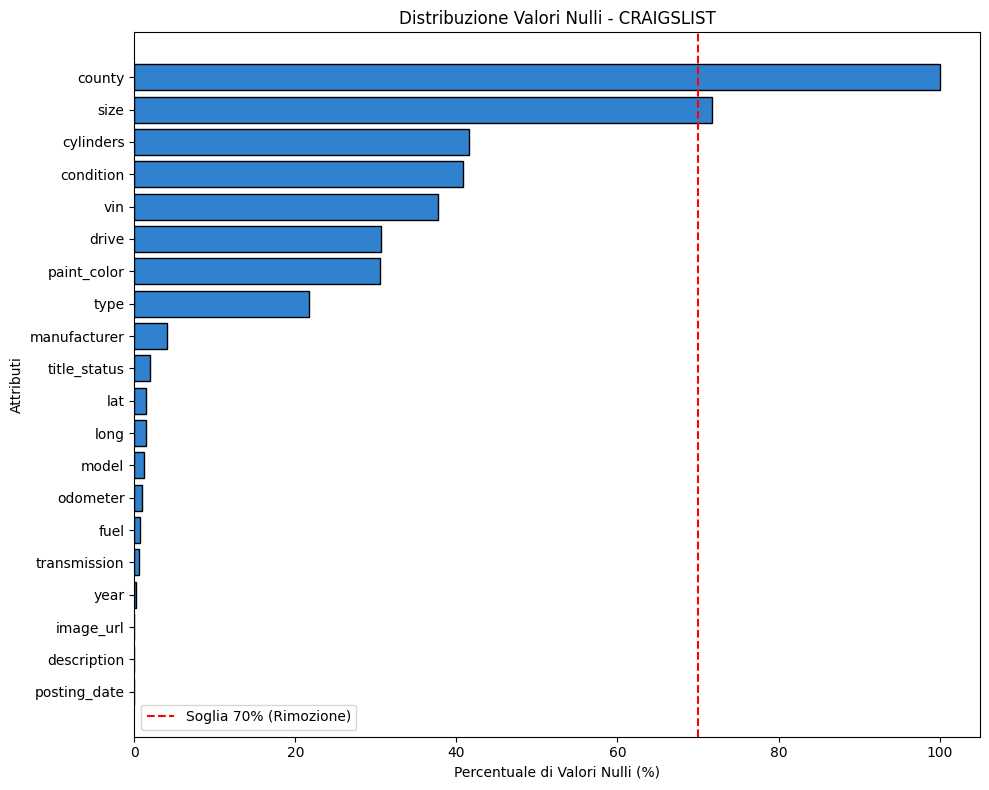

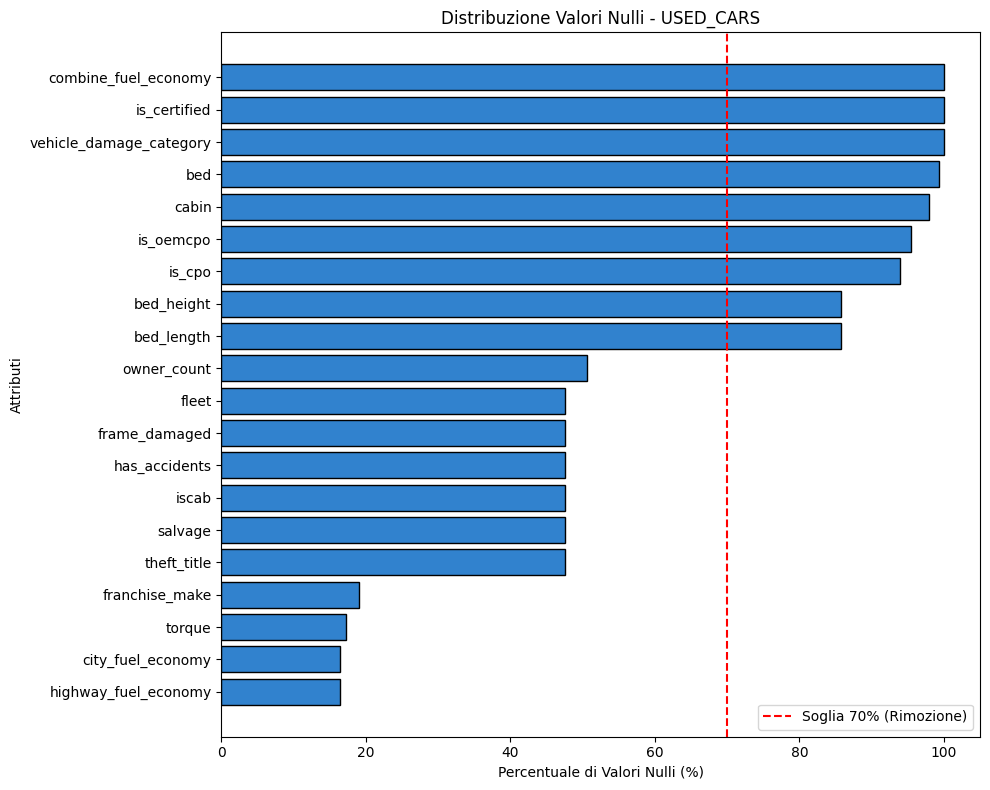

In [102]:
import matplotlib.pyplot as plt

def plot_null_percentages(report_df, title, top_n=20, soglia=70):
    data = report_df["Percentuale Nulli (%)"].sort_values(ascending=False).head(top_n)
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.barh(data.index[::-1], data.values[::-1], color="#3182ce", edgecolor="black")
    ax.axvline(soglia, color="red", linestyle="--", label=f"Soglia {soglia}% (Rimozione)")
    ax.set_xlabel("Percentuale di Valori Nulli (%)")
    ax.set_ylabel("Attributi")
    ax.set_title(f"Distribuzione Valori Nulli - {title}")
    ax.legend()
    plt.tight_layout()
    plt.savefig(f"null_distribution_{title.lower().replace(' ', '_')}.png", dpi=150)
    plt.show()

plot_null_percentages(report_vehicles, "CRAIGSLIST")
plot_null_percentages(report_used_cars, "USED_CARS")

## 2. Pulizia e Validazione dell'Attributo VIN

In [104]:
logger.info(f"Vehicles — Righe: {len(vehicles):,} | VIN nulli: {vehicles['vin'].isna().sum():,} | VIN unici: {vehicles['vin'].nunique():,}")
logger.info(f"Used Cars — Righe: {len(used_cars):,} | VIN nulli: {used_cars['vin'].isna().sum():,} | VIN unici: {used_cars['vin'].nunique():,}")

2026-09-13 10:00:36 | INFO     | Vehicles — Righe: 426,880 | VIN nulli: 161,042 | VIN unici: 118,264
2026-09-13 10:00:36 | INFO     | Used Cars — Righe: 3,000,040 | VIN nulli: 0 | VIN unici: 3,000,000


### Standardizzazione Formato VIN (Uppercase e Rimozione Spazi)

In [105]:
#Vehicles
vehicles["vin"] = (
    vehicles["vin"]
    .astype("string")
    .str.strip()
    .str.upper()
)

#Used Cars
used_cars["vin"] = (
    used_cars["vin"]
    .astype("string")
    .str.strip()
    .str.upper()
)

### Validazione Lunghezza VIN (Standard ISO 3779 = 17 Caratteri)

In [106]:
vehicles.loc[vehicles["vin"].str.len() != 17, "vin"] = pd.NA
used_cars.loc[used_cars["vin"].str.len() != 17, "vin"] = pd.NA

### Rimozione Record con VIN Non Valido o Nullo

In [107]:
vehicles = vehicles.dropna(subset=["vin"])
used_cars = used_cars.dropna(subset=["vin"])

### Verifica della Perdita Dati Post-Filtraggio VIN

In [108]:
logger.info(f"Vehicles dopo pulizia VIN: {len(vehicles):,} record")
logger.info(f"Used Cars dopo pulizia VIN: {len(used_cars):,} record")
logger.info(f"VIN Vehicles senza corrispondenza in Used Cars: {len(set(vehicles['vin']) - set(used_cars['vin'])):,} su {vehicles['vin'].nunique():,} VIN unici totali")

2026-09-13 10:00:36 | INFO     | Vehicles dopo pulizia VIN: 264,520 record
2026-09-13 10:00:36 | INFO     | Used Cars dopo pulizia VIN: 2,996,988 record
2026-09-13 10:00:40 | INFO     | VIN Vehicles senza corrispondenza in Used Cars: 113,408 su 117,355 VIN unici totali


### Identificazione dei VIN Comuni a Entrambe le Sorgenti

In [109]:
# uniformiamo ESPLICITAMENTE tipo e formato dei VIN
vehicles["vin"] = (
    vehicles["vin"]
    .astype("string")
    .str.strip()
    .str.upper()
)

used_cars["vin"] = (
    used_cars["vin"]
    .astype("string")
    .str.strip()
    .str.upper()
)

#eliminiamo i null solo per questa fase
vin_vehicles = vehicles["vin"].dropna().astype(str)
vin_used_cars = used_cars["vin"].dropna().astype(str)

#intersezione usando normali stringhe Python
common_vins = set(vin_vehicles) & set(vin_used_cars)

logger.info(f"VIN in comune identificati: {len(common_vins):,}")

#IMPORTANTE: portiamo anche le colonne a normali stringhe Python
vehicles["vin"] = vehicles["vin"].astype(str)
used_cars["vin"] = used_cars["vin"].astype(str)

vehicles_common = vehicles[
    vehicles["vin"].isin(common_vins)
].copy()

used_cars_common = used_cars[
    used_cars["vin"].isin(common_vins)
].copy()

logger.info(f"Vehicles (record comuni): {len(vehicles_common):,}")
logger.info(f"Used Cars (record comuni): {len(used_cars_common):,}")

2026-09-13 10:00:43 | INFO     | VIN in comune identificati: 3,947
2026-09-13 10:00:44 | INFO     | Vehicles (record comuni): 9,136
2026-09-13 10:00:44 | INFO     | Used Cars (record comuni): 3,947


### Analisi e Risoluzione dei VIN Duplicati

In [110]:
vehicles_clean=vehicles_common.copy()
used_cars_clean=used_cars_common.copy()

In [111]:
# CRAIGSLIST
conteggio_vin_v = (
    vehicles_clean["vin"]
    .value_counts()
)

duplicati_v = conteggio_vin_v[conteggio_vin_v > 1]

logger.info("Craigslist — Analisi duplicati:")
logger.info(f"VIN distinti: {vehicles_clean['vin'].nunique():,}")
logger.info(f"VIN che compaiono più di una volta: {len(duplicati_v):,}")
logger.info(f"Numero massimo di occorrenze dello stesso VIN: {conteggio_vin_v.max()}")

2026-09-13 10:00:44 | INFO     | Craigslist — Analisi duplicati:
2026-09-13 10:00:44 | INFO     | VIN distinti: 3,947
2026-09-13 10:00:44 | INFO     | VIN che compaiono più di una volta: 1,505
2026-09-13 10:00:44 | INFO     | Numero massimo di occorrenze dello stesso VIN: 235


In [112]:
# USED CARS
conteggio_vin_uc = (
    used_cars_clean["vin"]
    .value_counts()
)

duplicati_uc = conteggio_vin_uc[conteggio_vin_uc > 1]

logger.info("Used Cars — Analisi duplicati:")
logger.info(f"VIN distinti: {used_cars_clean['vin'].nunique():,}")
logger.info(f"VIN che compaiono più di una volta: {len(duplicati_uc):,}")
logger.info(f"Numero massimo di occorrenze dello stesso VIN: {conteggio_vin_uc.max()}")

2026-09-13 10:00:44 | INFO     | Used Cars — Analisi duplicati:
2026-09-13 10:00:44 | INFO     | VIN distinti: 3,947
2026-09-13 10:00:44 | INFO     | VIN che compaiono più di una volta: 0
2026-09-13 10:00:44 | INFO     | Numero massimo di occorrenze dello stesso VIN: 1


In [113]:
logger.info("Distribuzione frequenze occorrenze VIN (top 20):")
display(
    conteggio_vin_v
    .value_counts()
    .sort_index()
    .head(20)
)

2026-09-13 10:00:44 | INFO     | Distribuzione frequenze occorrenze VIN (top 20):


,count
count,
1,2442
2,670
3,283
4,170
5,100
6,94
7,52
8,34
9,25


In [114]:
check_vehicles = (
    vehicles_clean[
        vehicles_clean["vin"].duplicated(keep=False)
    ]
    .groupby("vin")
    .agg(
        n_record=("vin", "size"),
        n_manufacturer=("manufacturer", "nunique"),
        n_model=("model", "nunique"),
        n_year=("year", "nunique")
    )
    .reset_index()
)

check_vehicles.head(20)

,vin,n_record,n_manufacturer,n_model,n_year
0,19UDE2F73HA007339,2,1,1,1
1,19UUB1F51FA010464,3,1,1,1
2,19VDE1F51FE009875,4,1,1,1
3,19XFB2F58CE011648,6,1,1,1
4,19XFB2F90CE335048,2,1,1,1
5,19XFC1F96LE014283,8,1,1,1
6,1B3HB48B38D742294,3,1,1,1
7,1C3CCBBB3DN721764,2,1,1,1
8,1C3CCBCGXDN727524,2,1,1,1
9,1C3CCCAB0FN604072,2,1,1,1


In [115]:
duplicati_coerenti = check_vehicles[
    (check_vehicles["n_manufacturer"] == 1) &
    (check_vehicles["n_model"] == 1) &
    (check_vehicles["n_year"] == 1)
]

duplicati_sospetti = check_vehicles[
    (check_vehicles["n_manufacturer"] > 1) |
    (check_vehicles["n_model"] > 1) |
    (check_vehicles["n_year"] > 1)
]

logger.info(f"VIN duplicati coerenti: {len(duplicati_coerenti):,}")
logger.warning(f"VIN duplicati sospetti (conflitti su marca/modello/anno): {len(duplicati_sospetti):,}")

2026-09-13 10:00:44 | INFO     | VIN duplicati coerenti: 1,418
2026-09-13 10:00:44 | WARNING  | VIN duplicati sospetti (conflitti su marca/modello/anno): 63


In [116]:
vin_sospetti = duplicati_sospetti["vin"].head(10)

vehicles_clean[
    vehicles_clean["vin"].isin(vin_sospetti)
][
    ["vin", "manufacturer", "model", "year", "price", "odometer"]
].sort_values("vin")

,vin,manufacturer,model,year,price,odometer
50679,1C4BJWEG1FL755020,jeep,wrangler sahara,2015,29999,56881
65134,1C4BJWEG1FL755020,jeep,wrangler sahara 4x4,2015,29999,56881
78520,1C4PJMBS3GW155277,jeep,cherokee trailhawk sport,2016,17995,106245
78557,1C4PJMBS3GW155277,jeep,cherokee,2016,17995,106245
78954,1C4PJMBS3GW155277,jeep,cherokee,2016,17995,106245
78993,1C4PJMBS3GW155277,jeep,cherokee trailhawk sport,2016,18995,106245
79146,1C4PJMBS3GW155277,jeep,cherokee,2016,17995,106245
79447,1C4PJMBS3GW155277,jeep,cherokee,2016,17995,106245
79664,1C4PJMBS3GW155277,jeep,cherokee,2016,17995,106245
80114,1C4PJMBS3GW155277,jeep,cherokee,2016,17995,106245


In [117]:
colonne_utili = [
    "manufacturer",
    "model",
    "year",
    "price",
    "odometer",
    "fuel",
    "transmission",
    "state",
    "region",
    "description"
]

vehicles_clean["_completezza"] = (
    vehicles_clean[colonne_utili]
    .notna()
    .sum(axis=1)
)

In [118]:
vehicles_clean = (
    vehicles_clean
    .sort_values("_completezza", ascending=False)
    .drop_duplicates(subset="vin", keep="first")
    .drop(columns="_completezza")
    .reset_index(drop=True)
)

In [119]:
logger.info(f"Righe finali Vehicles: {len(vehicles_clean):,}")
logger.info(f"VIN distinti Vehicles: {vehicles_clean['vin'].nunique():,}")
logger.info(f"VIN duplicati rimasti: {vehicles_clean['vin'].duplicated().sum():,}")

2026-09-13 10:00:44 | INFO     | Righe finali Vehicles: 3,947
2026-09-13 10:00:44 | INFO     | VIN distinti Vehicles: 3,947
2026-09-13 10:00:44 | INFO     | VIN duplicati rimasti: 0


In [120]:
final_common_vins = (
    set(vehicles_clean["vin"])
    & set(used_cars_clean["vin"])
)

vehicles_clean = vehicles_clean[
    vehicles_clean["vin"].isin(final_common_vins)
].copy()

used_cars_clean = used_cars_clean[
    used_cars_clean["vin"].isin(final_common_vins)
].copy()

In [121]:
logger.info(f"Vehicles (record finali): {len(vehicles_clean):,} | VIN unici: {vehicles_clean['vin'].nunique():,}")
logger.info(f"Used Cars (record finali): {len(used_cars_clean):,} | VIN unici: {used_cars_clean['vin'].nunique():,}")

2026-09-13 10:00:44 | INFO     | Vehicles (record finali): 3,947 | VIN unici: 3,947
2026-09-13 10:00:44 | INFO     | Used Cars (record finali): 3,947 | VIN unici: 3,947


In [122]:
vehicles_clean.to_csv(
    "/content/drive/MyDrive/data/vehicles_vin_clean.csv",
    index=False
)

used_cars_clean.to_csv(
    "/content/drive/MyDrive/data/used_cars_vin_clean.csv",
    index=False
)

##Definizione dello Schema Mediato e Allineamento delle Sorgenti

Definiamo lo schema mediato unificato e mappiamo i campi eterogenei delle due sorgenti verso la struttura standard.

In [123]:
vehicles_aligned = pd.read_csv("/content/drive/MyDrive/data/vehicles_vin_clean.csv")
used_cars_aligned = pd.read_csv("/content/drive/MyDrive/data/used_cars_vin_clean.csv")

In [124]:
CRAIGSLIST_MAPPING = {
    "vin": "vin",
    "manufacturer": "make",
    "model": "model",
    "year": "year",
    "price": "price",
    "odometer": "mileage",
    "fuel": "fuel",
    "transmission": "transmission",
    "type": "body_type",
    "drive": "drivetrain",
    "cylinders": "cylinders",
    "paint_color": "color",
    "lat": "latitude",
    "long": "longitude",
    "posting_date": "listing_date",
    "description": "description"
}

USEDCARS_MAPPING = {
    "vin": "vin",
    "make_name": "make",
    "model_name": "model",
    "year": "year",
    "price": "price",
    "mileage": "mileage",
    "fuel_type": "fuel",
    "transmission": "transmission",
    "body_type": "body_type",
    "wheel_system": "drivetrain",
    "engine_cylinders": "cylinders",
    "listing_color": "color",
    "latitude": "latitude",
    "longitude": "longitude",
    "listed_date": "listing_date",
    "description": "description"
}


vehicles_aligned = vehicles_clean.rename(columns=CRAIGSLIST_MAPPING)
used_cars_aligned = used_cars_clean.rename(columns=USEDCARS_MAPPING)

In [125]:
MEDIATED_SCHEMA = [
    "vin",
    "make",
    "model",
    "year",
    "price",
    "mileage",
    "fuel",
    "transmission",
    "body_type",
    "drivetrain",
    "cylinders",
    "color",
    "latitude",
    "longitude",
    "listing_date",
    "description"
]

vehicles_aligned = vehicles_aligned[MEDIATED_SCHEMA]
used_cars_aligned = used_cars_aligned[MEDIATED_SCHEMA]

In [126]:
vehicles_aligned = vehicles_aligned.reindex(sorted(vehicles_aligned.columns),axis=1)
used_cars_aligned = used_cars_aligned.reindex(sorted(used_cars_aligned.columns),axis=1)

In [127]:
vehicles_aligned.to_csv(
    "/content/drive/MyDrive/data/vehicles_schema.csv",
    index=False
)

used_cars_aligned.to_csv(
    "/content/drive/MyDrive/data/used_cars_schema.csv",
    index=False
)

##Pulizia, Normalizzazione e Pre-processing dei Campi

Standardizziamo i valori categorici e numerici (`make`, `model`, `transmission`, `fuel`, `price`, `mileage`, `year`) per preparare i dataset allo schema mediato finale per il Record Linkage.

In [128]:
import pandas as pd

vehicles_schema = pd.read_csv("/content/drive/MyDrive/data/vehicles_schema.csv")
used_cars_schema = pd.read_csv("/content/drive/MyDrive/data/used_cars_schema.csv")

In [129]:
vehicles_schema["transmission"].unique()

array(['other', 'automatic', 'manual', None], dtype=object)

In [130]:
used_cars_schema["transmission"].unique()

array(['A', 'CVT', 'M', None, 'Dual Clutch'], dtype=object)

In [131]:
import pandas as pd


TRANSMISSION_MAPPING = {
    "automatic": "a",
    "cvt": "a",
    "manual": "m",
    "other": "o",
    "a": "a",
    "m": "m",
    "o": "o",
    "missing": "missing",
    "dual clutch": "a"
}


FUEL_MAPPING = {
    "gasoline": "gas",
    "gas": "gas",
    "flex fuel vehicle": "other",
    "biodiesel": "other",
    "other": "other",
    "electric": "electric",
    "hybrid": "hybrid",
    "diesel": "diesel",
    "missing": "missing"
}


def normalize_dataset(df):
    df = df.copy()

    text_cols = [
        "make",
        "model",
        "fuel",
        "transmission",
        "body_type",
        "drivetrain",
        "cylinders",
        "color"
    ]

    for col in text_cols:
        df[col] = (
            df[col]
            .astype("string")
            .str.strip()
            .str.lower()
            .str.replace(r"\s+", " ", regex=True)
        )

    df["transmission"] = df["transmission"].fillna("missing")
    df["fuel"] = df["fuel"].fillna("missing")

    df["transmission"] = df["transmission"].map(TRANSMISSION_MAPPING).fillna(df["transmission"])
    df["fuel"] = df["fuel"].map(FUEL_MAPPING).fillna(df["fuel"])

    numeric_cols = [
        "year",
        "price",
        "mileage",
        "latitude",
        "longitude"
    ]

    for col in numeric_cols:
        df[col] = pd.to_numeric(
            df[col],
            errors="coerce"
        )

    df["year"] = df["year"].astype("Int64")

    df["listing_date"] = pd.to_datetime(
        df["listing_date"],
        errors="coerce"
    )

    if "description" in df.columns:
        df["description"] = (
            df["description"]
            .astype("string")
            .str.strip()
            .str.replace(r"\s+", " ", regex=True)
        )

    return df


#assumendo che vehicles_schema e used_cars_schema siano stati caricati in precedenza
#vehicles_schema = pd.read_csv("vehicles.csv")
#used_cars_schema = pd.read_csv("used_cars.csv")

#IMPORTANTISSIMO: RICREO I DATASET DOPO AVER DEFINITO TUTTO
vehicles_schema = normalize_dataset(vehicles_schema)
used_cars_schema = normalize_dataset(used_cars_schema)

logger.info(f"Valori unici trasmissione Used Cars: {used_cars_schema['transmission'].unique().tolist()}")
logger.info(f"Valori unici trasmissione Vehicles: {vehicles_schema['transmission'].unique().tolist()}")

/usr/local/lib/python3.13/dist-packages/cudf/pandas/fast_slow_proxy.py:30: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  return fn(*args, **kwargs)


2026-09-13 10:00:46 | INFO     | Valori unici trasmissione Used Cars: ['a', 'm', 'missing']
2026-09-13 10:00:46 | INFO     | Valori unici trasmissione Vehicles: ['o', 'a', 'm', 'missing']


In [132]:
def preprocess_make(df):
    df = df.copy()

    df["make"] = (
        df["make"]
        .astype("string")
        .str.strip()                                  # spazi iniziali/finali
        .str.lower()                                  # tutto minuscolo
        .str.replace("-", " ", regex=False)           # trattini: spazio
        .str.replace("_", " ", regex=False)           # underscore: spazio
        .str.replace(r"[^\w\s]", " ", regex=True)     # altra punteggiatura
        .str.replace(r"\s+", " ", regex=True)         # spazi multipli: uno
        .str.strip()
    )

    return df


vehicles_schema = preprocess_make(vehicles_schema)
used_cars_schema = preprocess_make(used_cars_schema)

In [133]:
def preprocess_model(df):
    df = df.copy()

    df["model"] = (
        df["model"]
        .astype("string")
        .str.strip()                                  # spazi iniziali/finali
        .str.lower()                                  # tutto minuscolo
        .str.replace("-", " ", regex=False)           # trattini: spazio
        .str.replace("_", " ", regex=False)           # underscore: spazio
        .str.replace(r"[^\w\s]", " ", regex=True)     # altra punteggiatura
        .str.replace(r"\s+", " ", regex=True)         # spazi multipli: uno
        .str.strip()
    )

    return df


vehicles_schema = preprocess_model(vehicles_schema)
used_cars_schema = preprocess_model(used_cars_schema)

In [134]:
def preprocess_cylinders(df):
    df = df.copy()

    df["cylinders"] = (
        df["cylinders"]
        .astype("string")
        .str.lower()
        .str.extract(r"(\d+)", expand=False)
        .astype("Int64")
    )

    return df


vehicles_schema = preprocess_cylinders(vehicles_schema)
used_cars_schema = preprocess_cylinders(used_cars_schema)

In [135]:
def preprocess_mileage(df):
    df = df.copy()

    df["mileage"] = pd.to_numeric(
        df["mileage"],
        errors="coerce"
    )

    return df


vehicles_schema = preprocess_mileage(vehicles_schema)
used_cars_schema = preprocess_mileage(used_cars_schema)

In [136]:
def preprocess_price(df):
    df = df.copy()

    df["price"] = pd.to_numeric(
        df["price"],
        errors="coerce"
    )

    return df


vehicles_schema = preprocess_price(vehicles_schema)
used_cars_schema = preprocess_price(used_cars_schema)

In [137]:
vehicles_schema["price_num"] = vehicles_schema["price"]
used_cars_schema["price_num"] = used_cars_schema["price"]

In [138]:
def preprocess_year(df):
    df = df.copy()

    df["year"] = pd.to_numeric(
        df["year"],
        errors="coerce"
    )

    #gli anni non hanno parte decimale: 2018.0 -> 2018
    df["year"] = df["year"].astype("Int64")

    return df

In [139]:
vehicles_schema = preprocess_year(vehicles_schema)
used_cars_schema = preprocess_year(used_cars_schema)

In [140]:
vehicles_schema.to_csv(
    "/content/drive/MyDrive/data/vehicles_final.csv",
    index=False
)

used_cars_schema.to_csv(
    "/content/drive/MyDrive/data/used_cars_final.csv",
    index=False
)
logger.success("Dataset finali salvati con successo in:")
logger.info("- /content/drive/MyDrive/data/vehicles_final.csv")
logger.info("- /content/drive/MyDrive/data/used_cars_final.csv")

2026-09-13 10:00:47 | SUCCESS  | Dataset finali salvati con successo in:
2026-09-13 10:00:47 | INFO     | - /content/drive/MyDrive/data/vehicles_final.csv
2026-09-13 10:00:47 | INFO     | - /content/drive/MyDrive/data/used_cars_final.csv
